In [1]:
import sys
import os

sys.path.append("..")
if os.path.exists("/localscratch/code"):
    sys.path.append("/localscratch/code/PredTiler/src")
else:
    assert os.path.exists("/scratch/ashesh.ashesh/code/")
    sys.path.append("/scratch/ashesh.ashesh/code/PredTiler/src")
from data.tile_stitcher import stitch_predictions


In [ ]:
# ckpt = '2410/Hagen-joint_indi-l1/36'
# ckpt = '2502/HT_T24-joint_indi-l1/14'
# ckpt  = '2412/HT_LIF-joint_indi-l1/8'
# ckpt = '2501/COSEM_jrc-hela-joint_indi-l1/32'
# ckpt = '2502/COSEM_jrc-hela-joint_indi-l1/13'
# ckpt = '2502/COSEM_jrc-choroid-plexus-2-joint_indi-l1/5'
# ckpt = '2502/COSEM_jrc-choroid-plexus-2-joint_indi-l1/4'
ckpt_dir = "2502/Hagen-joint_indi-l1/63"
ckpt_time_predictor = "2502/Hagen-UnetClassifier-l2/11"

# ckpt = '2507/Hagen-joint_indi-l1/14'
eval_datasplit_type = "Test"
training_rootdir = "/group/jug/ashesh/training/diffsplit/"
num_steps_normalization = 10_000
# ckpt_time_predictor = '2507/Hagen-UnetClassifier-l2/4' #None
time_predictor = None
mixing_t_ood = 0.3
mmse_count = 50

batch_size = 4
num_workers = 4

num_timesteps = 1
enable_real_input = False
infer_time = True
use_aggregated_inferred_time = True
use_hardcoded_time_for_inference = None


# ====================
# calibration settings
# ====================
calibration_params_fpath = (
    None  # "./calibration_params_Val.pkl"  # the path from where one wants to load the calibration params
)
corr_pres_trans = True
# enable circular padded tranlation transform
enable_translation_transform = False
# we oscillate around the best t with a small delta
delta_t = 0.1
# homography transforms.
aug_theta_max = 0.0
aug_theta_z_max = 0
aug_shift_max = 0.0
enable_homography_transform = aug_theta_max > 0 or aug_theta_z_max > 0 or aug_shift_max > 0

# size of the block which is used to compute the correlation
elem_size = 10
# mmse_count = 50
# error is computed from the first prediction
compute_error_from_first_prediction = True
k_forward_pass = 2
learn_noise_characteristics = True

k_prediction_mode = "entire"
# whether to enable the hflip, vflip and 90 degree rotation
with_transforms = False
# apply input transforms to input.
with_inp_transforms = False
keep_original_input_fraction = 0.0
# when disable stochasticity is set to True, we pick the modes from the latent space
# instead of sampling from the distributions. But note that this also means that we get suboptimal prediction as well. To fix this, one may want to have two models.
disable_stochasticity = False

# this ensure that while we fit to 50 percentile, we pick the best fit on the basis of multiple percentiles and so is more robust.
enable_percentile_evaluation = True
# number of pixels to skip from each border while computing the error and variance
skip_pixels_err_var_computation = None
background_quantile = 0.01


noise_est_stability_count = 20
noise_est_num_steps = 6000

notebook_output_fpath = None  # where this notebook will be saved.

In [4]:
ckpt_dir = ckpt_dir.strip("/").strip(" ")
print(ckpt_dir)
assert eval_datasplit_type in ["Test", "Val"]

2502/Hagen-joint_indi-l1/63


In [5]:
if use_aggregated_inferred_time:
    assert ckpt_time_predictor is not None, "Time predictor is required for aggregated time inference"
    assert use_hardcoded_time_for_inference is use_hardcoded_time_for_inference, (
        "Hardcoded time inference is not supported with aggregated time inference"
    )
    assert infer_time is True, "Time inference must be enabled for aggregated time inference"


if infer_time:
    assert ckpt_time_predictor is not None, "Time predictor is required for time inference"

if use_hardcoded_time_for_inference is not None:
    assert not infer_time, "Time inference must be disabled for hardcoded time inference"

assert mixing_t_ood >= 0 and mixing_t_ood <= 1, "mixing_t_ood must be in [0, 1]"
assert enable_real_input is False, "Real input is not supported in this notebook."

In [6]:
import yaml
import os
import glob


def model_checkpoint_fpath(fname=None):
    ckpt_subdir = os.path.join(training_rootdir, ckpt_dir, "checkpoint")
    if fname is not None:
        return os.path.join(training_rootdir, ckpt_subdir, fname)
    else:
        list_of_files = glob.glob(ckpt_subdir + "/*_gen.pth")  # * means all if need specific format then *.csv
        latest_file = max(list_of_files, key=os.path.getctime)
        # best_files = [f for f in list_of_files if 'best_gen_' in f]
        # assert len(best_files) == 1,f'{best_files}'
        # best_file = best_files[0]
        fname = latest_file
        return os.path.join(ckpt_subdir, fname)


def model_checkpoint_fpath_prefix(fname=None):
    fpath = model_checkpoint_fpath(fname)
    suffix = "_gen.pth"
    assert fpath.endswith(suffix)
    return fpath[: -len(suffix)]


def load_config(ckpt):
    config_path = os.path.join(training_rootdir, ckpt, "wandb/latest-run/files/config.yaml")

    with open(config_path) as stream:
        try:
            opt = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)

    keys = ["name", "phase", "gpu_ids", "path", "datasets", "model", "train", "distributed"]
    output = {}
    for k in keys:
        if k in opt:
            output[k] = opt[k]["value"]
    return output

In [7]:
from model.ddpm_modules.time_predictor import TimePredictor
from time_prediction_training import get_datasets
import os
import torch

if ckpt_time_predictor is not None:
    time_pred_ckpt_fpath = os.path.join(training_rootdir, ckpt_time_predictor)

    time_pred_opt = load_config(time_pred_ckpt_fpath)
    time_pred_model_opt = time_pred_opt["model"]
    time_predictor = TimePredictor(
        in_channel=time_pred_model_opt["unet"]["in_channel"],
        out_channel=time_pred_model_opt["unet"]["out_channel"],
        norm_groups=time_pred_model_opt["unet"]["norm_groups"],
        inner_channel=time_pred_model_opt["unet"]["inner_channel"],
        channel_mults=time_pred_model_opt["unet"]["channel_multiplier"],
        attn_res=time_pred_model_opt["unet"]["attn_res"],
        res_blocks=time_pred_model_opt["unet"]["res_blocks"],
        dropout=time_pred_model_opt["unet"]["dropout"],
        image_size=time_pred_opt["datasets"]["patch_size"],
        initial_instance_norm=time_pred_model_opt["unet"].get("initial_instance_norm", False),
    )

    time_predictor = time_predictor.cuda()
    time_predictor.load_state_dict(
        torch.load(os.path.join(time_pred_ckpt_fpath, "best_time_predictor.pth")), strict=True
    )
    time_predictor.eval()
    print("Loaded time predictor from", time_pred_ckpt_fpath)


['UNet'] with in_channel 1, out_channel 1, norm_groups 16, image_size 512, initial_instance_norm False
TimePredictor
Loaded time predictor from /group/jug/ashesh/training/diffsplit/2502/Hagen-UnetClassifier-l2/11


In [8]:
opt = load_config(ckpt_dir)
opt["path"]["resume_state"] = model_checkpoint_fpath_prefix()
# opt['path']['resume_state'] = os.path.join(os.path.dirname(opt['path']['resume_state']),'I110000_E1375')
print(opt["path"]["resume_state"])

opt["model"]["beta_schedule"]["val"]["n_timestep"] = num_timesteps
if opt["datasets"]["train"]["name"] == "COSEM_jrc-hela":
    if eval_datasplit_type.lower() == "test":
        opt["datasets"]["val"]["datapath"] = opt["datasets"]["val"]["datapath"].replace("val_jrc_hela", "test_jrc_hela")

elif opt["datasets"]["train"]["name"].lower() == "hagen":
    opt["datasets"]["val"]["datapath"] = {
        "ch0": f"/group/jug/ashesh/data/scsplit_hagen/{eval_datasplit_type.lower()}/{eval_datasplit_type.lower()}_actin-60x-noise2-highsnr.tif",
        "ch1": f"/group/jug/ashesh/data/scsplit_hagen/{eval_datasplit_type.lower()}/{eval_datasplit_type.lower()}_mito-60x-noise2-highsnr.tif",
    }
elif opt["datasets"]["train"]["name"] in ["HT_LIF24", "HT_LIF", "BioSR", "HT_T24", "PaviaATN"]:
    if eval_datasplit_type.lower() == "test":
        opt["datasets"]["val"]["datapath"] = opt["datasets"]["val"]["datapath"].replace("/val", "/test")
else:
    raise NotImplementedError(f"Unknown dataset {opt['datasets']['train']['name']}")


/group/jug/ashesh/training/diffsplit/2502/Hagen-joint_indi-l1/63/checkpoint/I260000_E1625


In [9]:
for trainmode in ["train", "val"]:
    if isinstance(opt["datasets"][trainmode]["datapath"], str):
        opt["datasets"][trainmode]["datapath"] = opt["datasets"][trainmode]["datapath"].replace("diffsplit", "scsplit")
    elif isinstance(opt["datasets"][trainmode]["datapath"], dict):
        for k, v in opt["datasets"][trainmode]["datapath"].items():
            opt["datasets"][trainmode]["datapath"][k] = v.replace("diffsplit", "scsplit")

In [10]:
if "patch_size" not in opt["datasets"]:
    opt["datasets"]["patch_size"] = opt["datasets"]["train"]["patch_size"]

if "max_qval" not in opt["datasets"]:
    opt["datasets"]["max_qval"] = 0.98

if "uncorrelated_channels" not in opt["datasets"]["train"]:
    opt["datasets"]["train"]["uncorrelated_channels"] = False

if enable_real_input:
    opt["datasets"]["train"]["real_input_fraction"] = 1.0
    opt["datasets"]["val"]["real_input_fraction"] = 1.0

opt["datasets"]["normalize_channels"] = False

In [11]:
import torch
import data as Data
import model as Model
from data.split_dataset import SplitDataset, DataLocation
from split import get_datasets
import os


# data
train_set, val_set = get_datasets(opt, tiled_pred=True)

# model
diffusion = Model.create_model(opt)
diffusion.set_new_noise_schedule(opt["model"]["beta_schedule"][opt["phase"]], schedule_phase=opt["phase"])

# load checkpoint
diffusion.load_network()

Loading data from ('/group/jug/ashesh/data/scsplit_hagen/train/train_actin-60x-noise2-highsnr.tif', '/group/jug/ashesh/data/scsplit_hagen/train/train_mito-60x-noise2-highsnr.tif')


/localscratch/code/scSplit/notebooks/../data/split_dataset.py:125: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  data_ch0 = imread(fpaths[0], plugin='tifffile')
/localscratch/code/scSplit/notebooks/../data/split_dataset.py:126: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  data_ch1 = imread(fpaths[1], plugin='tifffile')


HARDCODED upperclip to 1993. Disable it if not needed !!!
Computing mean and std for normalization
[SplitDataset] Data: 80x2x(2048, 2048) Patch:512 Random:1 Aug:True Q:1.0 UpperClip:0Uncor:False InpFrmNormTar
Loading data from ('/group/jug/ashesh/data/scsplit_hagen/test/test_actin-60x-noise2-highsnr.tif', '/group/jug/ashesh/data/scsplit_hagen/test/test_mito-60x-noise2-highsnr.tif')


/localscratch/code/scSplit/notebooks/../data/split_dataset.py:125: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  data_ch0 = imread(fpaths[0], plugin='tifffile')
/localscratch/code/scSplit/notebooks/../data/split_dataset.py:126: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  data_ch1 = imread(fpaths[1], plugin='tifffile')


HARDCODED upperclip to 1993. Disable it if not needed !!!
[TilingDataset] Data: 10x2x(2048, 2048) Patch:512 Random:0 Aug:False Q:1.0 UpperClip:0Uncor:False InpFrmNormTar
['UNet'] with in_channel 1, out_channel 1, norm_groups 16, image_size 32, initial_instance_norm False
['UNet'] with in_channel 1, out_channel 1, norm_groups 16, image_size 32, initial_instance_norm False
[IndiFullTranslation]: Sampling mode: linear_indi, Noise mode: gaussian
[IndiFullTranslation]: Sampling mode: linear_indi, Noise mode: gaussian
[JointIndi]: w_input_loss: 0.1 
Scheduler set to ReduceLROnPlateau with patience:  100

--------------------------------------------------
Number of trainable parameters: 4.88M
--------------------------------------------------



In [12]:
type(val_set[0]["target"])

numpy.ndarray

In [13]:
from split import get_xt_normalizer

val_set.set_random_patching(True)
xt_normalizer1, xt_normalizer2 = get_xt_normalizer(
    val_set, opt["datasets"]["train"], num_bins=100, num_steps=num_steps_normalization
)
val_set.set_random_patching(False)

Random patching set to True


  0%|          | 0/8 [00:00<?, ?it/s]

10056 patches processed:  38%|███▊      | 3/8 [00:09<00:16,  3.29s/it]

Random patching set to False


True

In [14]:
xt_normalizer1.data_mean, xt_normalizer1.data_std

(tensor([333.3386, 330.8909, 332.6771, 328.7869, 327.6161, 329.5862, 328.1909,
         328.0685, 321.3260, 322.7504, 321.9721, 321.4484, 318.4454, 319.3729,
         318.8843, 313.8071, 313.7041, 312.6081, 312.5519, 311.8315, 310.3114,
         308.2919, 307.1227, 302.3158, 304.1329, 306.4594, 302.0035, 302.9470,
         299.4814, 300.3760, 295.3293, 295.3542, 294.7575, 293.0570, 292.8153,
         293.0992, 289.3021, 290.9484, 287.0280, 286.0516, 287.2185, 284.5060,
         286.7590, 285.1567, 280.7248, 281.8604, 279.6369, 277.6295, 277.6886,
         276.2981, 276.1706, 270.8286, 273.3422, 272.8954, 272.9288, 268.6331,
         265.4235, 264.7107, 263.6460, 263.1575, 262.3405, 259.9340, 257.7721,
         258.1634, 256.8268, 254.8638, 254.8608, 254.1098, 253.1613, 249.5912,
         250.9365, 247.3026, 248.6354, 243.6974, 245.2093, 245.5133, 243.3183,
         241.1334, 243.3709, 239.1042, 237.1326, 238.2506, 239.1100, 233.4186,
         233.8329, 234.1637, 232.8471, 231.9545, 229

In [15]:
from collections import defaultdict
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd


In [16]:
import numpy as np
import random


def fix_seeds():
    torch.manual_seed(0)
    torch.cuda.manual_seed(0)
    np.random.seed(0)
    random.seed(0)
    torch.backends.cudnn.deterministic = True


fix_seeds()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch

norm_dict = val_set.get_input_target_normalization_dict()

In [18]:
norm_dict.keys()

dict_keys(['mean_input', 'std_input', 'mean_channel', 'std_channel'])

In [19]:
diffusion.set_new_noise_schedule(opt["model"]["beta_schedule"]["val"], schedule_phase="val")


## Quantitative Evaluation using the classifier.
Here, we also inspect the effect of MMSE count.

In [20]:
if time_predictor is not None:
    t_pred1 = []
    t_pred2 = []
    with torch.no_grad():
        for i in tqdm(range(len(val_set))):
            data = val_set[i]
            inp_indi1 = data["target"][:1] * (1 - mixing_t_ood) + data["target"][1:2] * mixing_t_ood
            inp_indi2 = data["target"][:1] * mixing_t_ood + data["target"][1:2] * (1 - mixing_t_ood)
            inp_indi1 = torch.Tensor(inp_indi1[None]).cuda()
            inp_indi2 = torch.Tensor(inp_indi2[None]).cuda()
            # we can use mixing_t_ood for the normalization, because if it is real image, then we anyway have to normalize it separately.
            norm_inp1 = xt_normalizer1.normalize(
                inp_indi1.cuda(), torch.Tensor([mixing_t_ood] * len(inp_indi1)).cuda(), update=False
            )
            norm_inp2 = xt_normalizer2.normalize(
                inp_indi2.cuda(), torch.Tensor([mixing_t_ood] * len(inp_indi2)).cuda(), update=False
            )

            # time predictor notion of time is 1 - t, This formulation ensures that we have the time corresponding to indi1.
            t1 = 1 - time_predictor(norm_inp1)
            t2 = 1 - time_predictor(norm_inp2)
            t_pred1.append(t1.item())
            t_pred2.append(t2.item())

    t_pred1_aggregated = np.mean(t_pred1)
    t_pred2_aggregated = np.mean(t_pred2)
    print(t_pred1_aggregated, t_pred2_aggregated)
else:
    t_pred1_aggregated = None
    t_pred2_aggregated = None

  0%|          | 0/490 [00:00<?, ?it/s]

100%|██████████| 490/490 [00:15<00:00, 31.95it/s]

0.1864133426121303 0.7293592013874832


In [21]:
import torch.nn as nn
from model.scsplit_eval import EvaluationModel
from data.scsplit_eval import EvaluationSyntheticDset


In [22]:
if infer_time:
    assert use_aggregated_inferred_time is True
    # NOTE: This is a more stable mixing t and so, it yields better results over the paper.
    model_mixing_t_ood = (t_pred1_aggregated + (1 - t_pred2_aggregated)) / 2
    # model_mixing_t_ood = t_pred1_aggregated
elif use_hardcoded_time_for_inference is not None:
    model_mixing_t_ood = use_hardcoded_time_for_inference
else:
    model_mixing_t_ood = mixing_t_ood

print("Using model_mixing_t_ood =", model_mixing_t_ood, "mixing_t_ood =", mixing_t_ood)
dset_eval = EvaluationSyntheticDset(val_set, mixing_t_ood, xt_normalizer1)
model_eval = EvaluationModel(diffusion.netG, model_mixing_t_ood, num_timesteps=num_timesteps)

Using model_mixing_t_ood = 0.22852707061232352 mixing_t_ood = 0.3


In [23]:
inp, tar = dset_eval[2]
inp.shape, tar.shape, inp.mean(), tar.mean()

(torch.Size([1, 512, 512]),
 torch.Size([2, 512, 512]),
 tensor(-0.3982),
 tensor(-0.2683))

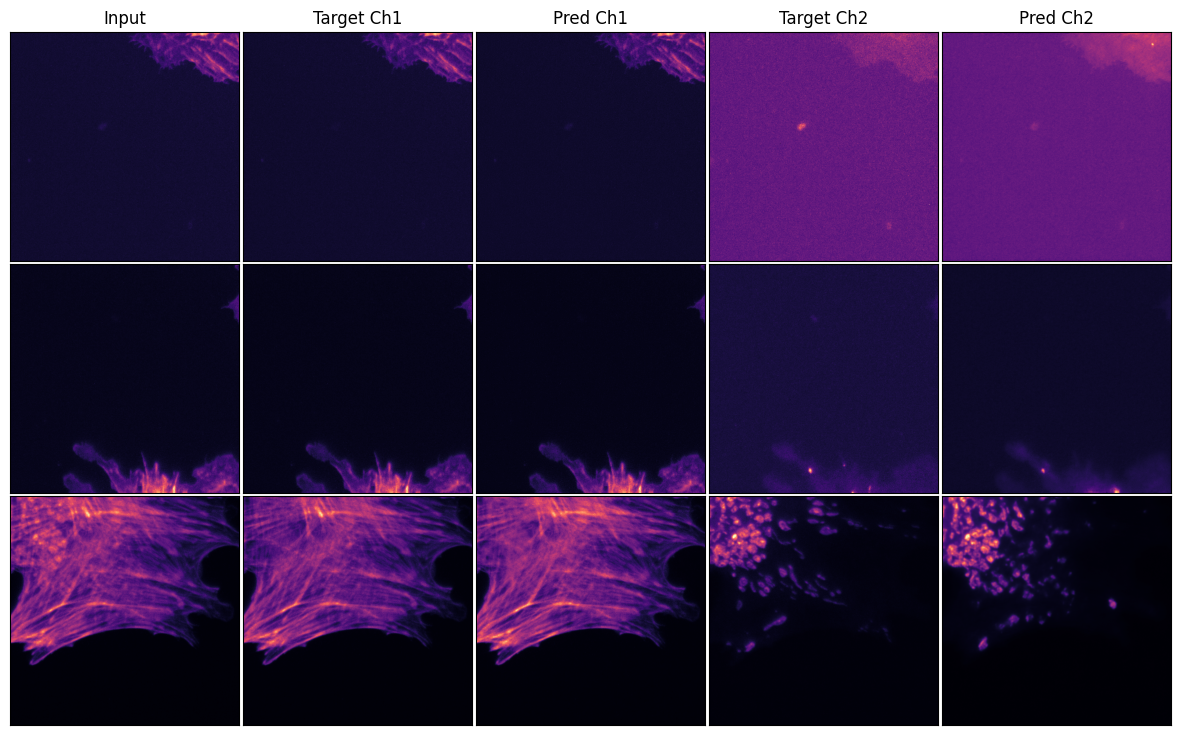

In [24]:
# plot inputs, targets, predictions
from disentangle.analysis.plot_utils import clean_ax


dloader = torch.utils.data.DataLoader(dset_eval, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)
for inp, tar in dloader:
    break

with torch.no_grad():
    pred = model_eval(inp.cuda())
pred.shape

ncols = 5
nrows = 3
fig, ax = plt.subplots(figsize=(3 * ncols, 3 * nrows), ncols=ncols, nrows=nrows)
for i in range(nrows):
    ax[i, 0].imshow(inp[i, 0].cpu(), cmap="magma")
    ax[i, 1].imshow(tar[i, 0].cpu(), cmap="magma")
    ax[i, 2].imshow(pred[i, 0].cpu(), cmap="magma")
    ax[i, 3].imshow(tar[i, 1].cpu(), cmap="magma")
    ax[i, 4].imshow(pred[i, 1].cpu(), cmap="magma")
    if i == 0:
        ax[i, 0].set_title("Input")
        ax[i, 1].set_title("Target Ch1")
        ax[i, 2].set_title("Pred Ch1")
        ax[i, 3].set_title("Target Ch2")
        ax[i, 4].set_title("Pred Ch2")

clean_ax(ax)
# reduce the gap between subplots
plt.subplots_adjust(wspace=0.01, hspace=0.01)

In [25]:
if skip_pixels_err_var_computation is None:
    skip_pixels_err_var_computation = opt["datasets"]["patch_size"] - opt["datasets"]["patch_size"] // 2

  0%|          | 0/123 [00:00<?, ?it/s]

100%|██████████| 123/123 [02:57<00:00,  1.44s/it]


[10, 2048, 2048, 1]
[10, 2048, 2048, 2]


100%|██████████| 50/50 [00:15<00:00,  3.20it/s]


Best t value: 0.8200000000000001
Obtained optimal mixing t from predictions: 0.8200000000000001


...

Learned parameters: alpha, beta, sigma 1.0949276685714722 0.07396015524864197 0.0009467819472774863 2.1173579692840576 1.048394799232483


loss: 0.004, alpha_dyn: 1.095, beta_dyn: 0.073, sigma_dyn: 0.001, std_loss: 0.000 poisson_loss: 41.941 alpha_poisson: 2.122 beta_poisson: 1.051: 100%|██████████| 6000/6000 [03:12<00:00, 31.12it/s]  


Learned parameters: alpha, beta, sigma 1.0949375629425049 0.07314422726631165 0.0009499808656983078 2.1218440532684326 1.0514496564865112
Transforms for Ch1: [('identity', {})]
Transforms for Ch2: [('identity', {})]
Using correlation preserving transforms
Using transform types: {0: [Identity(transform_type='identity')], 1: [Identity(transform_type='identity')]}


[PosteriorSampler] k_forward_pass: 1
[PosteriorSampler] mixing_t range: [0.7200000000000001, 0.9], mu: 0.07283476144075393, sigma: 1.093741202354431, gaussian_noise_std: 0.0010379396146163345


100%|██████████| 123/123 [03:03<00:00,  1.49s/it]


[10, 2048, 2048, 2]
[10, 2048, 2048, 2]


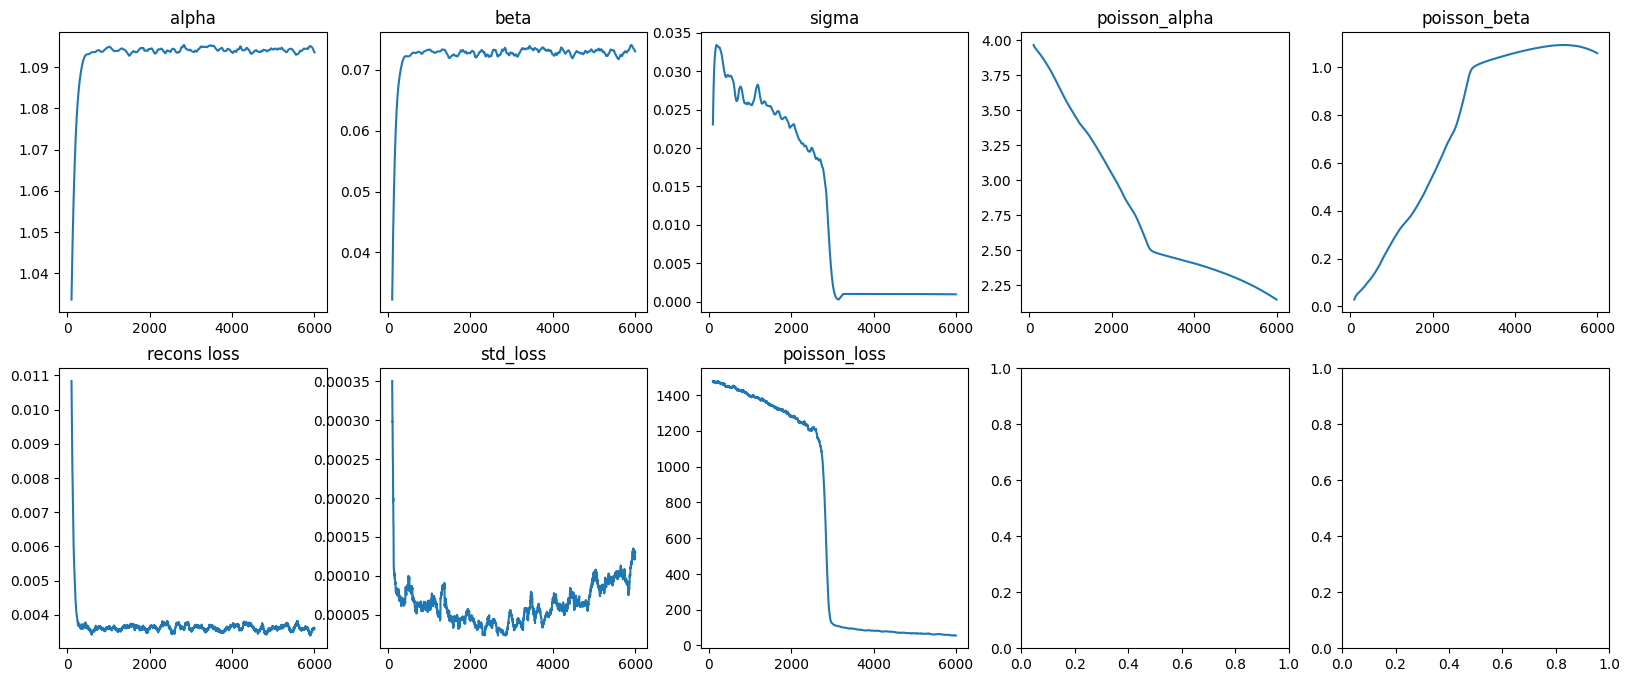

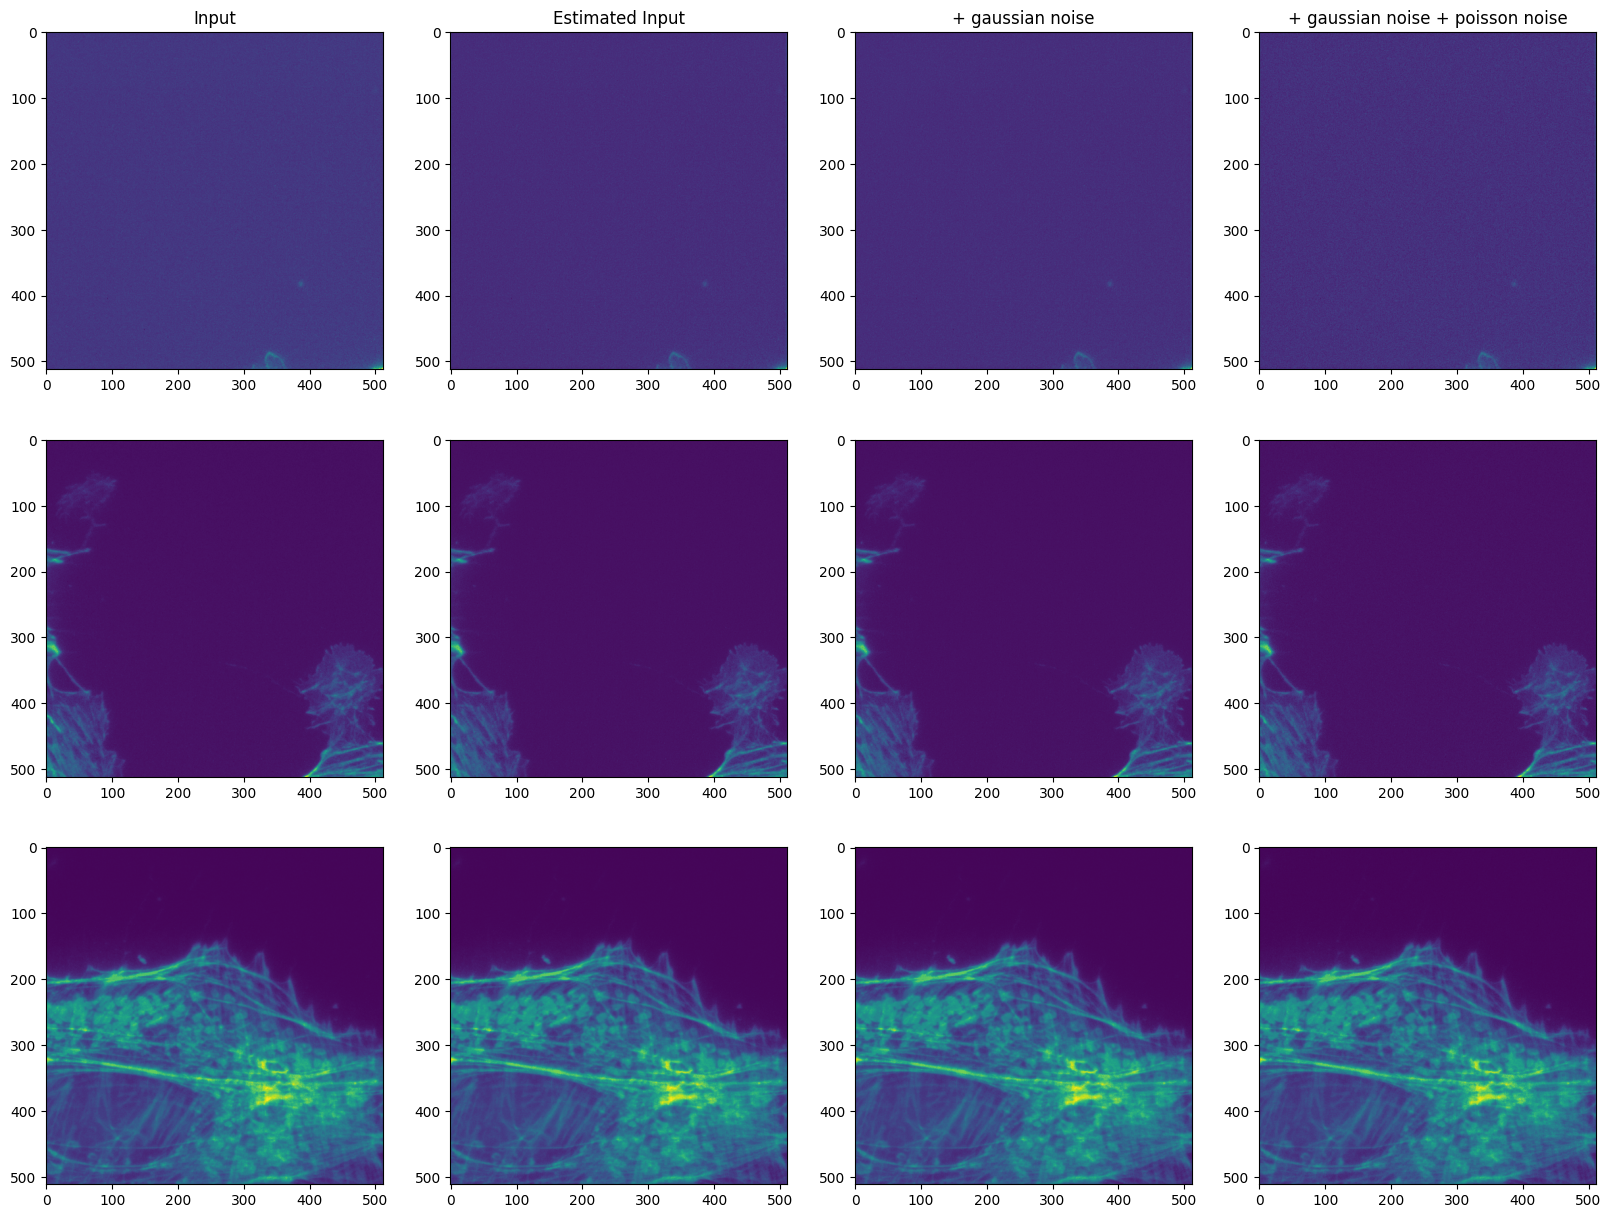

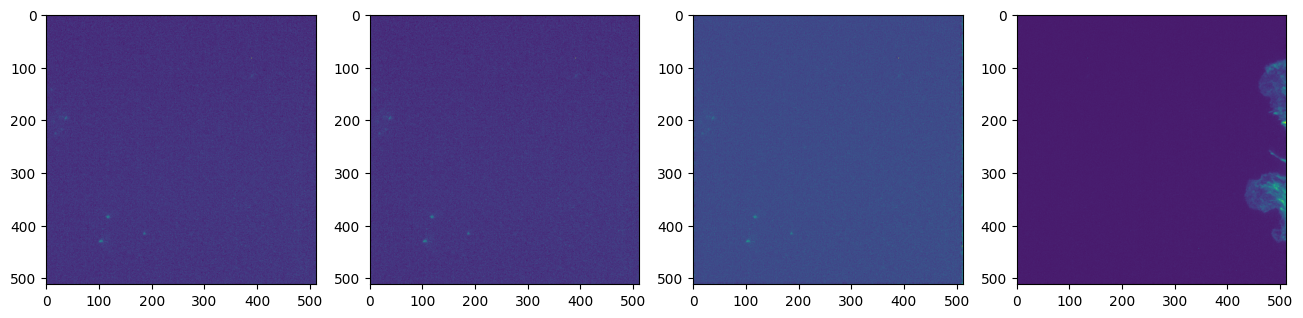

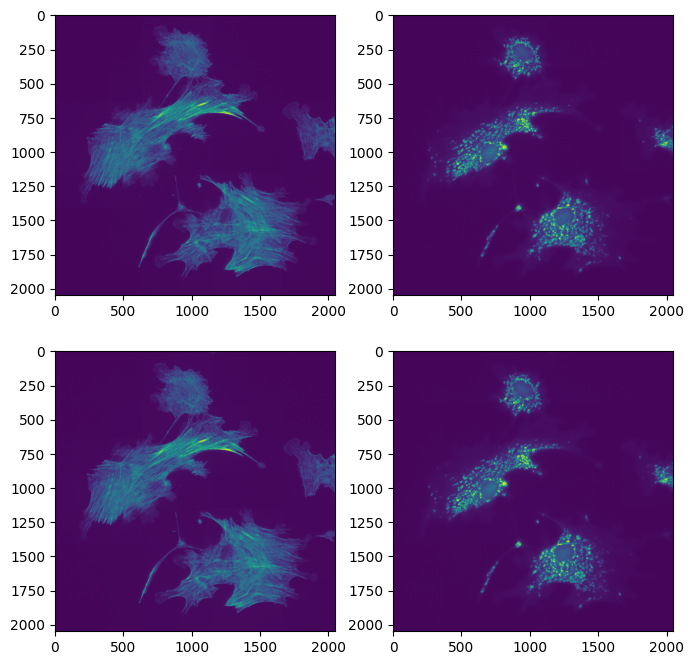

In [28]:
# uq_processor.quantify()
from finetunesplit.posterior_sampler import PosteriorSampler
from finetunesplit.calibration.find_optimal_parameters import find_optimal_params
from finetunesplit.calibration.grid_search import plot_coverage_plot
from finetunesplit.uq_quantification import UncertaintyQuantification
from core.psnr import RangeInvariantPsnr

plot = True
stitch_predictions_func = lambda prediction, dset: stitch_predictions(prediction, dset.tile_manager)

uq_processor = UncertaintyQuantification(
    model_eval,
    None,
    dset_eval,
    metric_func_for_mixingratio=RangeInvariantPsnr,
    stitch_function=stitch_predictions_func,
    tqdm_disable=False,
)
homography_transform_params = None
if enable_homography_transform:
    homography_transform_params = {
        "theta_max": aug_theta_max,
        "theta_z_max": aug_theta_z_max,
        "shift_max": aug_shift_max,
        "device": "cuda",
    }
    print("Enabling homography transform", homography_transform_params)

transforms_config = {
    "correlation_preserving_transforms": corr_pres_trans,
    "with_pred_transforms": with_transforms,
    "with_inp_transforms": with_inp_transforms,
    "enable_translation_transform": enable_translation_transform,
    "homography_transform_params": homography_transform_params,
    "enable_percentile_evaluation": enable_percentile_evaluation,
}
err_and_var_config = {
    "percentiles_to_evaluate": [10, 20, 30, 40, 50, 60, 70, 80, 90],
    "skip_pixels": skip_pixels_err_var_computation,
    "elem_size": elem_size,
    "compute_error_from_first_prediction": compute_error_from_first_prediction,
}


pred_dict = uq_processor.get_input_tar_pred(
    uq_processor._val, uq_processor.model, batch_size=batch_size, mmse_count=mmse_count, num_workers=num_workers
)

# get optimal mixing ratio from input and predictions
mixing_t_pred = uq_processor.optimal_mixing_ratio(pred_dict["inp"], pred_dict["pred"])
print("Obtained optimal mixing t from predictions:", mixing_t_pred)

# get estimated input patches
estimated_inp_patches = uq_processor.get_estimated_inp(pred_dict["pred"], mixing_t_pred)
normalized_inp_patches = pred_dict["inp"]

# use estimated input patches to learn noise parameters
noise_params = uq_processor.estimate_input_noise_params(
    normalized_inp_patches,
    estimated_inp_patches,
    stability_count=noise_est_stability_count,
    num_steps=noise_est_num_steps,
    plot=plot,
)

# now, we have the forward operator parameters
forward_operator_params = uq_processor.get_forward_operator_params(mixing_t_pred, delta_t, noise_params)

# get transforms
transform_dict = uq_processor.get_transforms(
    correlation_preserving_transforms=transforms_config["correlation_preserving_transforms"],
    with_pred_transforms=transforms_config["with_pred_transforms"],
    with_inp_transforms=transforms_config["with_inp_transforms"],
    enable_translation_transform=transforms_config["enable_translation_transform"],
    homography_transform_params=transforms_config["homography_transform_params"],
    enable_percentile_evaluation=transforms_config["enable_percentile_evaluation"],
)


def create_input(normalized_prediction, mixing_ratio):
    mean, std = xt_normalizer1.get_mean_std(torch.Tensor([0, 1]))
    assert len(normalized_prediction.shape) == 4
    mean = mean.reshape(1, -1, 1, 1).to(normalized_prediction.device)
    std = std.reshape(1, -1, 1, 1).to(normalized_prediction.device)
    # print(mean.shape, std.shape, normalized_prediction.shape)
    denorm_pred = normalized_prediction * std + mean
    inp = dset_eval.create_input(denorm_pred, mixing_ratio)
    # print(inp.shape)
    return inp


# instantiate the sampler
psampler = PosteriorSampler(
    uq_processor.model,
    transform_dict["pred_transform"],
    forward_operator_params=forward_operator_params,
    mmse_count=mmse_count,
    k_forward_pass=k_forward_pass,
    input_transforms=transform_dict["inp_transform"],
    keep_original_input_fraction=keep_original_input_fraction,
    create_input_func=create_input,
)

_ = uq_processor.test_sampler(psampler, plot=plot)

# now, get err and var
err, var, pred_b, one_step_pred_mmse = uq_processor.get_err_and_var(
    uq_processor.model, psampler, batch_size=batch_size, num_workers=num_workers, uq_params=err_and_var_config
)
if plot:
    uq_processor.plot_err_var(pred_b, one_step_pred_mmse, var, err)

In [29]:
if calibration_params_fpath is not None:
    import pickle

    print("Loading calibration params from", calibration_params_fpath)
    with open(calibration_params_fpath, "rb") as f:
        calibration_params = pickle.load(f)
    factors_shifted = calibration_params["factors_shifted"]
    offsets_shifted = calibration_params["offsets_shifted"]
    q_var = calibration_params["q_var"]
    q_err = calibration_params["q_err"]
    achieved_percentiles = calibration_params["achieved_percentiles"]
    assert notebook_output_fpath is None, (
        "One does not need to save the notebook output when loading calibration params"
    )
else:
    output, metadata = find_optimal_params(
        err,
        var,
        percentiles_to_evaluate=err_and_var_config["percentiles_to_evaluate"],
        q_bkg=background_quantile,
        around_center=False,
    )
    factors_shifted, offsets_shifted = output
    print("Optimal factors:", factors_shifted)
    print("Optimal offsets:", offsets_shifted)
    q_var = metadata["q_var"]
    q_err = metadata["q_err"]
    achieved_percentiles = metadata["achieved_percentiles"]

Offset based on background quantile 0.00093417964
Offset based on background quantile 0.00057312043
Starting the grid search
4.73 10 D0
11.02 20 D0
16.21 30 D0
20.58 40 D0
Upscaling 10 -> 20
24.41 50 D0
31.14 70 D0
36.72 90 D0
41.37 110 D0
Upscaling 20 -> 40
44.86 130 D0
49.41 170 D0
52.04 210 D1
49.41 170 D2
50.88 190.0 D3
50.18 180.0 D3
49.82 175.0 D4
50.18 180.0 D5
50.01 177.5 D5
49.92 176.25 D6
50.01 177.5 D7
Using 44.86 percentile for 50, Factor:170 Error:16.524973770387565

Starting the grid search
9.90 10 D0
24.28 20 D0
37.18 30 D0
47.37 40 D0
Upscaling 10 -> 20
55.28 50 D1
37.18 30 D2
47.37 40.0 D2
51.53 45.0 D3
47.37 40.0 D4
49.54 42.5 D4
50.55 43.75 D5
49.54 42.5 D6
50.05 43.125 D7
Using 49.54 percentile for 50, Factor:43.75 Error:7.193453213622608

Optimal factors: [170, 43.75]
Optimal offsets: [0, 0.0]


In [30]:
import pickle

calibration_params = {
    "q_var": np.array(q_var).tolist(),
    "q_err": np.array(q_err).tolist(),
    "achieved_percentiles": np.array(achieved_percentiles).tolist(),
    "factors_shifted": factors_shifted,
    "offsets_shifted": offsets_shifted,
    "mmse_count": mmse_count,
}
for key, val in calibration_params.items():
    print(f"{key}: {val}")

if notebook_output_fpath is not None:
    print(f"Saving calibration params to {notebook_output_fpath}")
    with open(notebook_output_fpath, "wb") as f:
        pickle.dump(calibration_params, f)

q_var: [8.590112884121481e-06, 1.894384877232369e-05]
q_err: [0.0009427697514183819, 0.0005920642870478332]
achieved_percentiles: [50.008266302101546, 50.04673550881298]
factors_shifted: [170, 43.75]
offsets_shifted: [0, 0.0]
mmse_count: 10


LeftOriented: Channel 0 MAE 18.73, MAX Err 41.68
LeftOriented: Channel 1 MAE 8.70, MAX Err 18.46


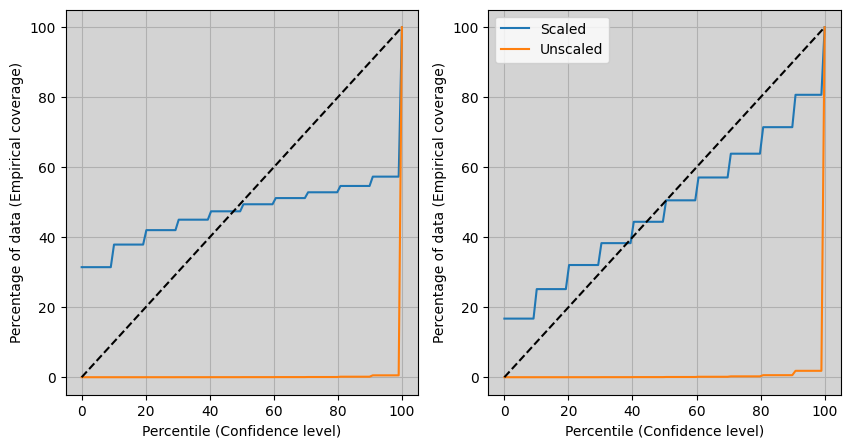

In [31]:
data_left_oriented = plot_coverage_plot(
    var - np.array(q_var)[None, :, None],
    err,
    factors_shifted,
    [k + q_err[i] for i, k in enumerate(offsets_shifted)],
    around_center=False,
)

perfect = np.linspace(0, 100, 100)
mean_err_arr = []
max_err_arr = []
for col_idx in range(var.shape[1]):
    act = data_left_oriented[col_idx]["scaled"][1]
    mean_err = np.abs(perfect - act).mean()
    max_err = np.abs(perfect - act).max()
    mean_err_arr.append(mean_err)
    max_err_arr.append(max_err)
    print(f"LeftOriented: Channel {col_idx} MAE {mean_err:.2f}, MAX Err {max_err:.2f}")


In [ ]:
from metrics import compute_stats


def get_raw_target():
    ch0 = np.stack(dset_eval.dset._data_dict[0])
    ch1 = np.stack(dset_eval.dset._data_dict[1])
    tar = np.stack([ch0, ch1], axis=-1)
    return tar


pred = stitch_predictions(pred_dict["pred"], dset_eval.tile_manager)


def print_ignored_pixels():
    ignored_pixels = 1
    while (
        pred[
            0,
            -ignored_pixels:,
            -ignored_pixels:,
        ].std()
        == 0
    ):
        ignored_pixels += 1
    ignored_pixels -= 1
    print(f"In {pred.shape}, last {ignored_pixels} many rows and columns are all zero.")
    return ignored_pixels


ignored_pixels_in_data = print_ignored_pixels()
assert ignored_pixels_in_data == 0, "We do not expect any ignored pixels here."

tar = get_raw_target()


# sep_mean, sep_std = model_eval.data_mean, model_eval.data_std
sep_mean, sep_std = dset_eval.normalizer.get_mean_std(torch.Tensor([0, 1]))
if isinstance(sep_mean, dict):
    sep_mean = sep_mean["target"]
    sep_std = sep_std["target"]

sep_mean = sep_mean.squeeze()[None, None, None]
sep_std = sep_std.squeeze()[None, None, None]
pred_unnormalized = pred * sep_std.cpu().numpy() + sep_mean.cpu().numpy()
stats_dict = compute_stats(tar, pred_unnormalized)
print(
    f"W:{mixing_t_ood}_P{dset_eval.tile_manager.patch_shape[-1]}_G{dset_eval.tile_manager.grid_shape[-1]}_M{mmse_count}_Sk{ignored_pixels_in_data}"
)


[10, 2048, 2048, 2]
In (10, 2048, 2048, 2), last 0 many rows and columns are all zero.
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/localscratch/code/Disentangle/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/localscratch/code/Disentangle/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /localscratch/code/Disentangle/.venv/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 10/10 [00:04<00:00,  2.38it/s]
/localscratch/code/MicroSSIM/src/microssim/ssim/ssim_utils.py:297: RuntimeWarning: invalid value encountered in sqrt
  term = 2 * alpha * np.sqrt(elements.vx * elements.vy) + elements.C2
100%|██████████| 10/10 [00:04<00:00,  2.38it/s]


PSNR:	 17.74+-0.517	19.9+-0.425
MicroSSIM:	 0.596+-0.035	0.736+-0.024
MicroS3IM:	 0.722+-0.027	0.818+-0.020
SSIM:	 0.696+-0.028	0.842+-0.017
MSSSIM:	 0.725+-0.027	0.828+-0.020
lpips:	 0.427+-0.036	0.285+-0.027
W:0.3_P512_G256_M10_Sk0
